<a href="https://colab.research.google.com/github/putvejs/fita-ml-course/blob/main/week1_week1_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")


✓ Visas bibliotēkas ielādētas veiksmīgi


In [2]:
# Ielādē datu kopu tieši no UCI repozitorija
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
print(df.head())


Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0

In [3]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)


Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [4]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())


Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [5]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())


Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [6]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")


Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']
Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


In [7]:
# Kuras kolonnas satur trūkstošas vērtības?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Kolonnas ar trūkstošām vērtībām:")
print(missing)


Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)


In [8]:
# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")


✓ Trūkstošo vērtību nav — dati ir tīri!


In [9]:
# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")


In [10]:
# Kategoriskām kolonnām — moda
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")



In [11]:
# Galīgā pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())



✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


In [12]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])  # Parāda pirmos 10


Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


In [13]:
# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")


✓ Boolean kolonnas konvertētas uz 0/1


In [14]:
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])


✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


In [15]:
# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Ja ir atlikušās kategoriskās kolonnas, mēģiniet tās pārvērst par skaitliskām (jo tām vajadzētu būt 0/1)
if len(remaining_cat) > 0:
    print(f"Brīdinājums: Atrastas neapstrādātas kategoriskas kolonnas: {remaining_cat}. Mēģinu konvertēt uz int.")
    for col in remaining_cat:
        # Mēģiniet konvertēt uz int, ja iespējams. Kļūdu gadījumā, ignorējiet vai attiecīgi rīkojieties.
        try:
            df[col] = df[col].astype(int)
            print(f"✓ Kolonna '{col}' konvertēta uz int.")
        except ValueError as e:
            print(f"Kļūda konvertējot '{col}': {e}. Atstājot to kā ir.")
    # Pārskatiet atlikušās kategoriskās kolonnas pēc konvertēšanas mēģinājuma
    remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

assert len(remaining_cat) == 0, f"Vēl neapstrādātas kategoriskās kolonnas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikt: ", len(remaining_cat))

Brīdinājums: Atrastas neapstrādātas kategoriskas kolonnas: ['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']. Mēģinu konvertēt uz int.
✓ Kolonna 'Month_Dec' konvertēta uz int.
✓ Kolonna 'Month_Feb' konvertēta uz int.
✓ Kolonna 'Month_Jul' konvertēta uz int.
✓ Kolonna 'Month_June' konvertēta uz int.
✓ Kolonna 'Month_Mar' konvertēta uz int.
✓ Kolonna 'Month_May' konvertēta uz int.
✓ Kolonna 'Month_Nov' konvertēta uz int.
✓ Kolonna 'Month_Oct' konvertēta uz int.
✓ Kolonna 'Month_Sep' konvertēta uz int.
✓ Kolonna 'VisitorType_Other' konvertēta uz int.
✓ Kolonna 'VisitorType_Returning_Visitor' konvertēta uz int.
✓ Visas kategoriskās kolonnas kodētas. Atlikt:  0


In [16]:
# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Dati tipi:")
print(df.dtypes.value_counts())



Kolonnu skaits pēc kodēšanas: 27
Dati tipi:
int64      20
float64     7
Name: count, dtype: int64


In [17]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10])  # Parāda pirmos 10


Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


In [18]:
# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))



=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    34.47           31.73                  1194.75  
std                    140.75           44.48                  1913.67  
min                      0.00            0.00                     0.00  
25%     

In [19]:
from sklearn.preprocessing import StandardScaler

# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']


In [20]:
# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))


✓ 26 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                     0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.41           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.77           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                    -0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.7

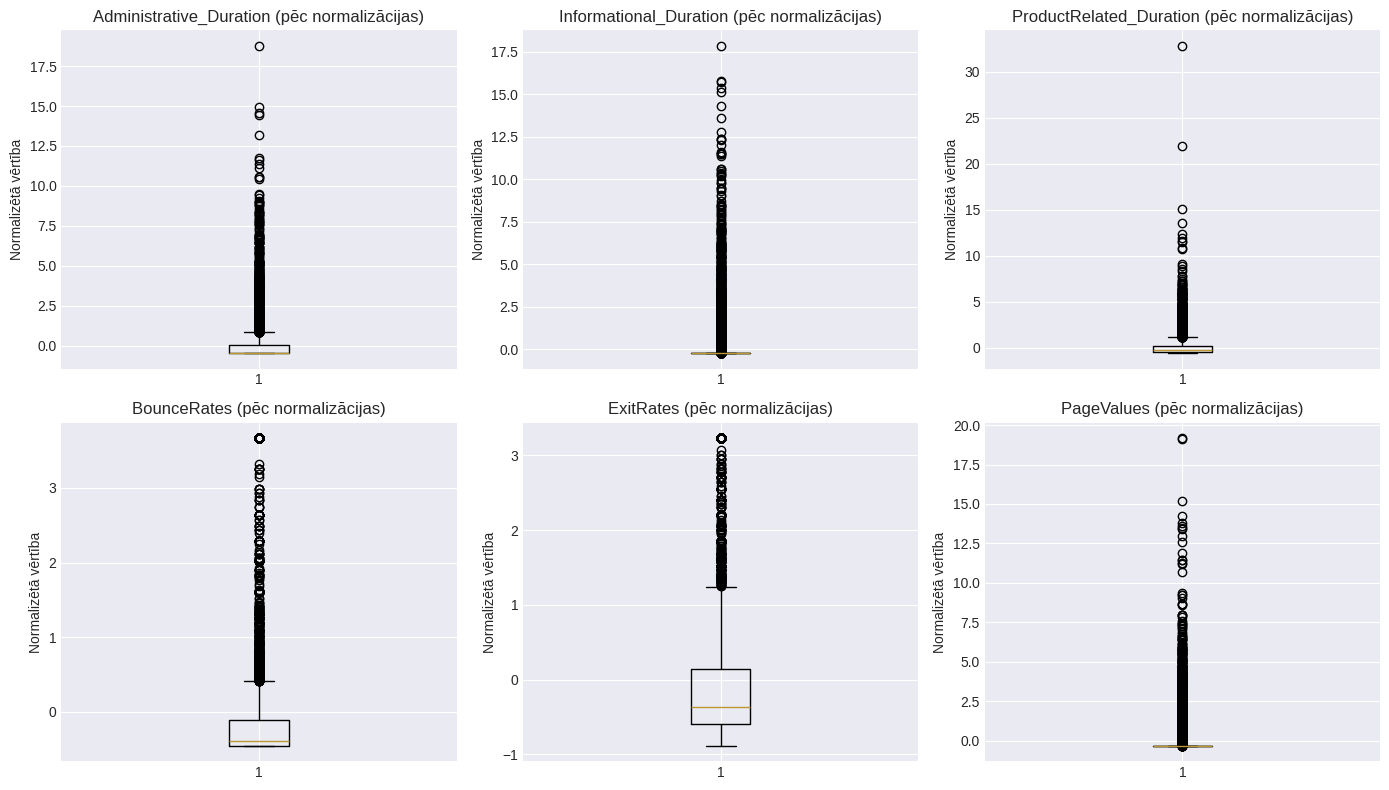

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [21]:
# Salīdzinājums:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")


In [22]:
# Izveido jaunu kolonnu 'TotalDuration' kā visu veidu apmeklējumu laika summu
df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

print("✓ Jaunas iezīmes izveidotas")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jaunas iezīmes izveidotas
Datu kopas forma tagad: (12330, 28)


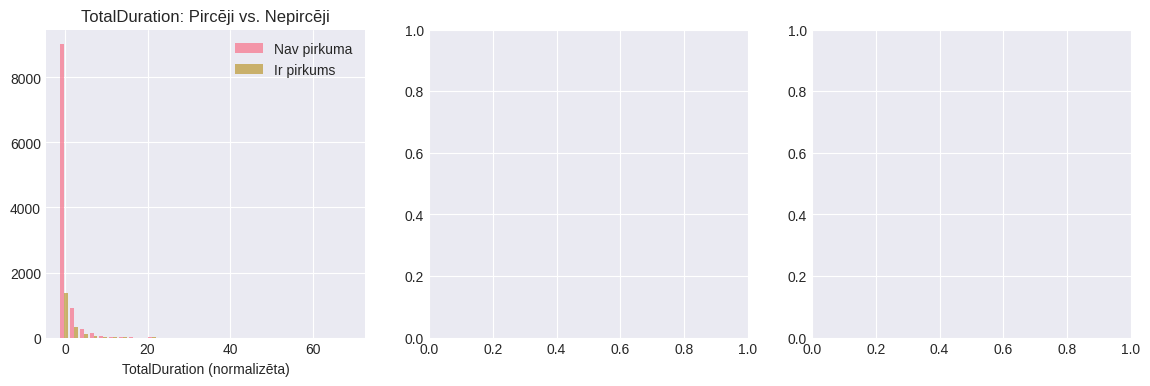

In [23]:
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Piemērs ar TotalDuration (aprēķins ir redzams slaidos)
axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()


In [24]:
# Vidējie
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['TotalDuration'].mean(),
            df[df['Revenue'] == 1]['TotalDuration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')


Text(399.13562091503275, 0.5, 'Vērtība')

In [25]:
# Box plot
df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2])
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")


<Figure size 640x480 with 0 Axes>

✓ Jaunā iezīme analizēta un vizualizēta


In [26]:
# Saglabā tīro datu kopu nākamajajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")


✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28


In [27]:
# Pārbaudi, vai fails ir nolasāms
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
print(df_check.head(2))


✓ Fails pārbaudīts: (12330, 28)
Pirmās rindas:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.457191      -0.396478   
1       -0.696993                -0.457191      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244931       -0.691003                -0.624348   
1               -0.244931       -0.668518                -0.590903   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Jul  Month_June  \
0     3.667189   3.229316   -0.317178   -0.308821  ...  -0.190548   -0.154649   
1    -0.457683   1.171473   -0.317178   -0.308821  ...  -0.190548   -0.154649   

   Month_Mar  Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   
1  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   

   VisitorType_Returning_Visitor  TotalDuration  
0                       0.

In [28]:
# Ielādē tikko sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")


Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))


=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.82      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



In [32]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



In [33]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))


            Modelis  F1 Score
      Decision Tree  0.632201
      Random Forest  0.635258
Logistic Regression  0.481416


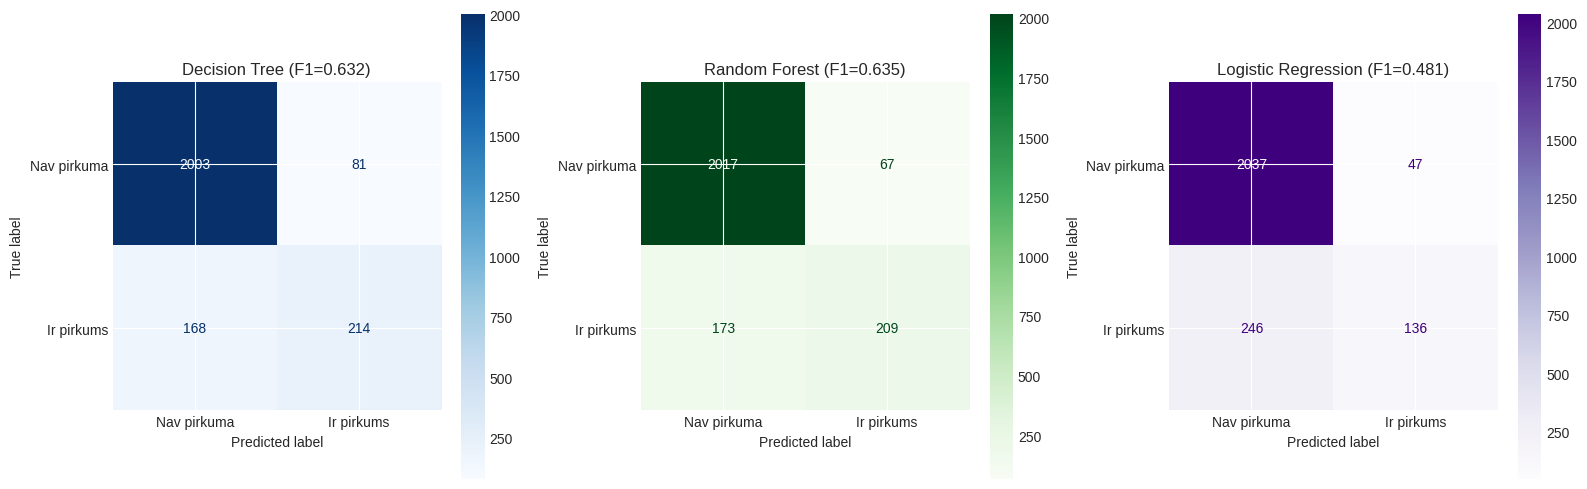

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()


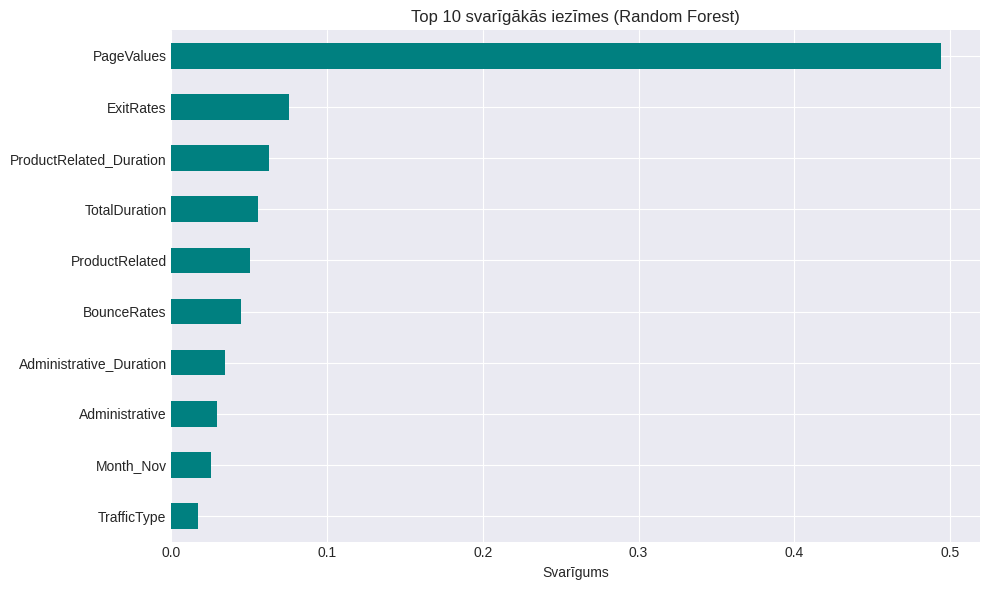

In [35]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 2. Papildu modeļu salīdzinājums ar kross-validāciju

Pievienojam **GradientBoosting** un **SVM** modeļus. Visus modeļus salīdzinām ar 5-fold kross-validāciju (F1 score), lai izvēlētos optimālo.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Ielādē tīros datus
df = pd.read_csv('shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Target balance: {y.value_counts().to_dict()}")


In [ ]:
# Definē visus modeļus
models = {
    'Decision Tree':        DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Logistic Regression':  LogisticRegression(random_state=42, max_iter=1000),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(probability=True, random_state=42),
}

# 5-fold kross-validācija
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f"{name:22s}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:
# Iztrenē visus modeļus uz pilnas treniņa kopas un novērtē testa kopā
test_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_mean = cv_results[name].mean()
    test_results.append({'Modelis': name, 'CV F1 (mean)': cv_mean,
                         'Test F1': f1, 'ROC AUC': auc})

results_df = pd.DataFrame(test_results).sort_values('ROC AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())


## 3. ROC līknes — visu modeļu vizuāls salīdzinājums

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'forestgreen', 'tomato', 'darkorange', 'purple']

for (name, model), color in zip(fitted_models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC līknes — visu modeļu salīdzinājums')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. PageValue — galvenā iezīme un tās ietekme uz pirkuma prognozi

`PageValue` ir vidējā lapas vērtība, ko lietotājs apmeklēja pirms pirkuma. Tas ir viens no spēcīgākajiem prognozētājiem.

In [ ]:
# PageValue sadalījums starp pircējiem un nepircējiem (pirms normalizācijas)
df_raw = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramma
axes[0].hist(df_raw[df_raw['Revenue'] == False]['PageValues'], bins=40,
             alpha=0.6, label='Nav pirkuma', color='steelblue')
axes[0].hist(df_raw[df_raw['Revenue'] == True]['PageValues'], bins=40,
             alpha=0.6, label='Ir pirkums', color='tomato')
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Skaits')
axes[0].set_title('PageValues sadalījums pēc Revenue')
axes[0].legend()

# Box plot
df_raw.boxplot(column='PageValues', by='Revenue', ax=axes[1])
axes[1].set_title('PageValues: pircēji vs. nepircēji')
axes[1].set_xlabel('Revenue (False=Nav pirkuma, True=Ir pirkums)')
axes[1].set_ylabel('PageValues')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Vidējās vērtības
print("Vidējais PageValues:")
print(df_raw.groupby('Revenue')['PageValues'].mean().rename({False: 'Nav pirkuma', True: 'Ir pirkums'}))


In [ ]:
# Korelācija ar Revenue (skaitliskās kolonnas)
df_raw_encoded = df_raw.copy()
df_raw_encoded['Revenue'] = df_raw_encoded['Revenue'].astype(int)
df_raw_encoded['Weekend'] = df_raw_encoded['Weekend'].astype(int)

numeric_only = df_raw_encoded.select_dtypes(include='number')
corr_with_revenue = numeric_only.corr()['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
corr_with_revenue.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr_with_revenue])
plt.axvline(0, color='black', lw=0.8)
plt.title('Korelācija ar Revenue (mērķa mainīgo)')
plt.xlabel('Pearson korelācija')
plt.tight_layout()
plt.show()

print("
Top 5 korelētākās iezīmes ar Revenue:")
print(corr_with_revenue.head(5))


## 5. Optimālais modelis — secinājums

In [ ]:
best_row = results_df.iloc[0]
best_name = best_row['Modelis']
best_model = fitted_models[best_name]

print("=" * 55)
print(f"  OPTIMĀLAIS MODELIS: {best_name}")
print("=" * 55)
print(f"  CV F1  : {best_row['CV F1 (mean)']:.4f}")
print(f"  Test F1: {best_row['Test F1']:.4f}")
print(f"  ROC AUC: {best_row['ROC AUC']:.4f}")
print("=" * 55)

# Detalizēts klasifikācijas pārskats
from sklearn.metrics import classification_report
y_pred_best = best_model.predict(X_test)
print(f"
Klasifikācijas pārskats ({best_name}):")
print(classification_report(y_test, y_pred_best, target_names=['Nav pirkuma', 'Ir pirkums']))

# Iezīmju svarīgums (ja pieejams)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(10)
    plt.figure(figsize=(9, 5))
    feat_imp.plot(kind='barh', color='teal')
    plt.title(f'Top 10 svarīgākās iezīmes — {best_name}')
    plt.xlabel('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
